## importing toolbox ^ ^


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from matplotlib import pyplot as plt 
import seaborn as sns


## Reading and explore the data 

In [2]:
data=pd.read_csv('data.csv')

In [3]:
data.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
11,84610002,M,15.78,17.89,103.60,781.0,0.09710,0.12920,0.09954,0.06606,...,20.42,27.28,136.50,1299.0,0.1396,0.5609,0.3965,0.18100,0.3792,0.10480
189,874839,B,12.30,15.90,78.83,463.7,0.08080,0.07253,0.03844,0.01654,...,13.35,19.59,86.65,546.7,0.1096,0.1650,0.1423,0.04815,0.2482,0.06306
364,9010877,B,13.40,16.95,85.48,552.4,0.07937,0.05696,0.02181,0.01473,...,14.73,21.70,93.76,663.5,0.1213,0.1676,0.1364,0.06987,0.2741,0.07582
394,903554,B,12.10,17.72,78.07,446.2,0.10290,0.09758,0.04783,0.03326,...,13.56,25.80,88.33,559.5,0.1432,0.1773,0.1603,0.06266,0.3049,0.07081
300,892438,M,19.53,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.10620,...,25.93,26.24,171.10,2053.0,0.1495,0.4116,0.6121,0.19800,0.2968,0.09929


In [4]:
data.shape

(569, 32)

In [5]:
print(data.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                567 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                563 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
null_data=data.isnull().sum()
print(null_data)

id                         0
diagnosis                  2
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  6
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## Fill some missing values and drop other 

In [8]:
mean = np.mean(data['area_mean'])
data['area_mean']=data['area_mean'].fillna(mean)
data=data.dropna()

## Labeling the data

In [9]:
lb=LabelEncoder()
data.diagnosis =lb.fit_transform(data.diagnosis)

In [10]:
data.diagnosis.value_counts()

diagnosis
0    357
1    210
Name: count, dtype: int64

## Calculate the corr with target

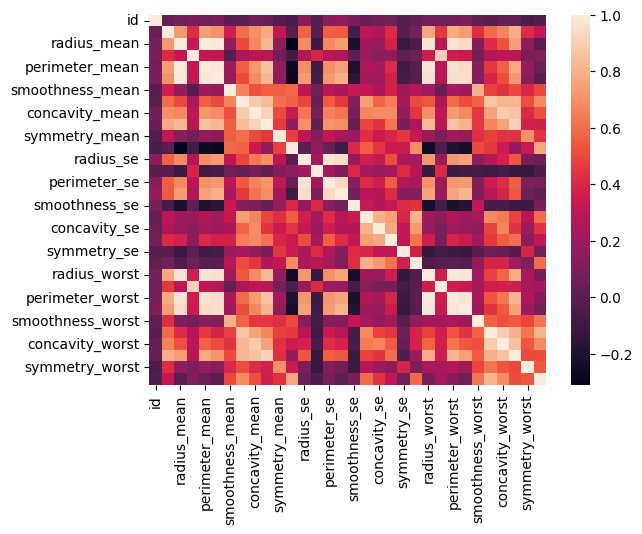

<Figure size 1500x1500 with 0 Axes>

In [68]:
corr = data.corr()
sns.heatmap(corr)
plt.figure(figsize=(15,15))
plt.tight_layout()

## top 10 features

In [93]:
corr_matrix=data.drop('diagnosis',axis=1).corrwith(data.diagnosis)
top10=corr_matrix.sort_values(ascending=False).head(10)
top10.index

Index(['concave points_worst', 'perimeter_worst', 'concave points_mean',
       'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean',
       'area_mean', 'concavity_mean', 'concavity_worst'],
      dtype='object')

## X and y split

In [11]:
X=data.drop('diagnosis',axis=1)
y=data['diagnosis']

## Scalering the data

In [12]:
st =StandardScaler()
X = st.fit_transform(X)

## over sampling the data

In [13]:
ros = RandomOverSampler(random_state=41)
X_res,y_res = ros.fit_resample(X,y)

## splitting the data

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X_res,y_res,test_size=0.3,random_state=41)

## models setup

In [15]:
model1=L=LogisticRegression()
model2=SVC()
model3=RandomForestClassifier()
model4=XGBClassifier()
model5=GradientBoostingClassifier()

## Creating function to perfome models

In [16]:
def pred(model):
    model.fit(X_train,y_train)
    pred= model.predict(X_test)
    print(classification_report(y_test,pred))

## Perform models

In [17]:
pred(model1)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       113
           1       0.97      0.96      0.97       102

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [18]:
pred(model2)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       113
           1       0.97      0.96      0.97       102

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [19]:
pred(model3)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       113
           1       0.97      0.98      0.98       102

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [20]:
pred(model4)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       113
           1       0.97      0.98      0.98       102

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [21]:
pred(model5)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       113
           1       0.96      0.97      0.97       102

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



## we found that a XGBclassifier is the best model so now we have to tune hyper params

## we use GridsearchCV from sklearn

In [ ]:
param_grid = {
    'learning_rate' : [0.001 , 0.01 , 0.1 ,1],
    'max_depth' : [3 , 10 ,25],
    'n_estimators' : [10,20,50,100],

}
grid_search = GridSearchCV(estimator=model4, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [23]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1],
                         'max_depth': [3, 10, 25],
                         'n_estimators': [10, 20, 50, 100]},
             scoring='accuracy')

In [25]:
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

## save model as file in format "pkl" using pickle

In [27]:
import pickle 
with open('final_model.pkl','wb') as file:
    pickle.dump(model4,file)